In [ ]:
# Удаление пропущенных значений
df = df.dropna(subset=['ds', 'y'])
df = df.sort_values('ds').reset_index(drop=True)

data_train.tail(-5) и head

_ = если два графика отображаются (в ВС коде один)
_ = plot_acf(original_df.target, lags=60)
plt.grid()

In [ ]:
print(model.summary())

In [ ]:
print(model.params()) ????

Тесты Дики-Фуллера (ADF) и KPSS

Полагаться только на визуальный анализ рискованно — иногда тренд или сезонность могут быть не так очевидны. Чтобы принять объективное решение, используют статистические тесты. Самый популярный из них — расширенный тест Дики-Фуллера (Augmented Dickey-Fuller Test, ADF). 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
import math #### все функции
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve
from IPython.display import display, HTML
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

from sympy import *

import mpl_toolkits.mplot3d as p3
import random
import time


from functools import partial
#from ipywidgets import interact, RadioButtons, IntSlider, FloatSlider, Dropdown, BoundedFloatText
from numpy.linalg import norm

from scipy import sparse

random.seed(42) # начальное состояние генератора случайных чисел, чтобы можно было воспроизводить результаты.

#!unzip «путь_до_архива»
#Всё извлечётся в память Colab.

In [3]:
# plotting
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

# не ЕTNA модели Prophet, TBATS, SARIMAX — модели для предсказания временных рядов
import statsmodels

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima

# make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

In [1]:
import pandas as pd
import numpy as np

from etna.datasets.tsdataset import TSDataset

# модели
from etna.models import (NaiveModel, 
                         MovingAverageModel, 
                         SeasonalMovingAverageModel,
                         HoltWintersModel)

from etna.models import ProphetModel
from etna.models import CatBoostMultiSegmentModel


from etna.pipeline import Pipeline


from etna.metrics import MAE, MSE, SMAPE, MAPE

# аналитика
from etna.analysis import plot_forecast
from etna.analysis import plot_backtest
from etna.analysis import plot_feature_relevance
from etna.analysis import ModelRelevanceTable
from statsmodels.graphics.tsaplots import plot_acf

# трансформации
from etna.transforms import MeanTransform, LagTransform
from sklearn.ensemble import RandomForestRegressor


%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore')

начало ДЗ по товарам и магазинам

In [34]:
import pandas as pd

from etna.datasets.tsdataset import TSDataset
from etna.transforms import (
    StandardScalerTransform,
    MeanTransform, 
    LagTransform,
    DateFlagsTransform)

from etna.pipeline import Pipeline
from etna.metrics import SMAPE

import warnings
warnings.filterwarnings('ignore')

from etna.analysis import plot_forecast

In [35]:
HORIZON = 90

smape = SMAPE()

In [7]:
# модная функция !!!!!!!не использовал
def train_and_evaluate_model(ts, 
                             model,
                             transforms,
                             horizon,
                             metrics,
                             print_metrics=True,
                             return_forecast=False,
                             n_train_samples=0):
    """"
    Обучает модель, вычисляет прогнозы для 
    тестовой выборки и строит график прогнозов. 
    """

    train_ts, test_ts = ts.train_test_split(test_size=horizon)
    pipe = Pipeline(model=model,
                    transforms=transforms,
                    horizon=horizon)
    pipe.fit(train_ts)
    forecast_ts = pipe.forecast()

    # оцениваем качество прогнозов по сегментам
    segment_metrics = metrics(test_ts, forecast_ts)
    segment_metrics = pd.Series(segment_metrics)
    
    avg_metric = sum(segment_metrics) / len(segment_metrics)
    
    if print_metrics:
        print(f"Avg (by segments) metric {metrics} is: {avg_metric}")
    
    if n_train_samples > 0:
        plot_forecast(forecast_ts, test_ts, 
                      train_ts, n_train_samples=n_train_samples)

    if return_forecast:
        return segment_metrics, avg_metric, forecast_ts
    
    return segment_metrics, avg_metric

In [ ]:
# не из примера
df = pd.read_csv('/workspaces/pyt_begin/data_data/data_T/train.csv', parse_dates=['date'], dtype={
    'store': 'int64',
    'item': 'int64',
    'sales': 'int64'
})

In [37]:
df = pd.read_csv('/workspaces/pyt_begin/data_data/data_T/train.csv', parse_dates=['date'])

df.rename(columns={'date': 'timestamp', 
                   'sales': 'target'}, inplace=True)
df

,timestamp,store,item,target
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
829064,2013-03-02,5,46,33
829065,2013-03-03,5,46,38
829066,2013-03-04,5,46,21
829067,2013-03-05,5,46,33


In [38]:
df_new = pd.read_csv('/workspaces/pyt_begin/data_data/data_T/test.csv', parse_dates=['date'])

df_new.rename(columns={'date': 'timestamp', 
                   'sales': 'target'}, inplace=True)

df_new.drop(columns='id', inplace=True)

df_new

,timestamp,store,item
0,2018-01-01,1,1
1,2018-01-02,1,1
2,2018-01-03,1,1
3,2018-01-04,1,1
4,2018-01-05,1,1
...,...,...,...
44995,2018-03-27,10,50
44996,2018-03-28,10,50
44997,2018-03-29,10,50
44998,2018-03-30,10,50


In [39]:
df['segment'] = (df['store'].astype(str) + ' + ' 
                 + df['item'].astype(str))

df_new['segment'] = (df_new['store'].astype(str) + ' + ' 
                     + df_new['item'].astype(str))

df.head()

,timestamp,store,item,target,segment
0,2013-01-01,1,1,13,1 + 1
1,2013-01-02,1,1,11,1 + 1
2,2013-01-03,1,1,14,1 + 1
3,2013-01-04,1,1,13,1 + 1
4,2013-01-05,1,1,10,1 + 1


In [40]:
for col in ['store', 'item']:
    df[col] = df[col].astype('category')
    df_new[col] = df_new[col].astype('category')

In [41]:
regressor_df = df[['timestamp', 'segment', 'store', 'item']].copy()
regressor_df

,timestamp,segment,store,item
0,2013-01-01,1 + 1,1,1
1,2013-01-02,1 + 1,1,1
2,2013-01-03,1 + 1,1,1
3,2013-01-04,1 + 1,1,1
4,2013-01-05,1 + 1,1,1
...,...,...,...,...
829064,2013-03-02,5 + 46,5,46
829065,2013-03-03,5 + 46,5,46
829066,2013-03-04,5 + 46,5,46
829067,2013-03-05,5 + 46,5,46


In [42]:
# экзогенных переменные store и item
regressor_df_new = df_new.copy()
regressor_df_new

,timestamp,store,item,segment
0,2018-01-01,1,1,1 + 1
1,2018-01-02,1,1,1 + 1
2,2018-01-03,1,1,1 + 1
3,2018-01-04,1,1,1 + 1
4,2018-01-05,1,1,1 + 1
...,...,...,...,...
44995,2018-03-27,10,50,10 + 50
44996,2018-03-28,10,50,10 + 50
44997,2018-03-29,10,50,10 + 50
44998,2018-03-30,10,50,10 + 50


In [43]:
regressor_df = regressor_df.sort_index(
    axis=1, ascending=False)

regressor_df_new = regressor_df_new.sort_index(
    axis=1, ascending=False)

In [44]:
regressor_df.shape, regressor_df_new.shape, regressor_df.shape[0] + regressor_df_new.shape[0]

((829069, 4), (45000, 4), 874069)

In [13]:
regressor_df.columns, regressor_df_new.columns

(Index(['timestamp', 'store', 'segment', 'item'], dtype='object'),
 Index(['timestamp', 'store', 'segment', 'item'], dtype='object'))

In [45]:
regressor_df = pd.concat([regressor_df, regressor_df_new], axis=0)
regressor_df['quarter'] = regressor_df['timestamp'].dt.quarter
regressor_df['quarter_start'] = regressor_df['timestamp'].dt.is_quarter_start
regressor_df['quarter_end'] = regressor_df['timestamp'].dt.is_quarter_end
regressor_df

,timestamp,store,segment,item,quarter,quarter_start,quarter_end
0,2013-01-01,1,1 + 1,1,1,True,False
1,2013-01-02,1,1 + 1,1,1,False,False
2,2013-01-03,1,1 + 1,1,1,False,False
3,2013-01-04,1,1 + 1,1,1,False,False
4,2013-01-05,1,1 + 1,1,1,False,False
...,...,...,...,...,...,...,...
44995,2018-03-27,10,10 + 50,50,1,False,False
44996,2018-03-28,10,10 + 50,50,1,False,False
44997,2018-03-29,10,10 + 50,50,1,False,False
44998,2018-03-30,10,10 + 50,50,1,False,False


In [46]:
# подготавливаем исторический набор эндогенных переменных
df.drop(['store', 'item'], axis=1, inplace=True)
df

,timestamp,target,segment
0,2013-01-01,13,1 + 1
1,2013-01-02,11,1 + 1
2,2013-01-03,14,1 + 1
3,2013-01-04,13,1 + 1
4,2013-01-05,10,1 + 1
...,...,...,...
829064,2013-03-02,33,5 + 46
829065,2013-03-03,38,5 + 46
829066,2013-03-04,21,5 + 46
829067,2013-03-05,33,5 + 46


до мультииндекса все норм, после него флоат 2.0

стоп

In [22]:
#мультииндекс это пандас ДФ
df = TSDataset.to_dataset(df)
df

segment,1 + 1,1 + 10,1 + 11,1 + 12,1 + 13,1 + 14,1 + 15,1 + 16,1 + 17,1 + 18,...,9 + 41,9 + 42,9 + 43,9 + 44,9 + 45,9 + 5,9 + 6,9 + 7,9 + 8,9 + 9
feature,target,target,target,target,target,target,target,target,target,target,...,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13.0,37.0,37.0,33.0,37.0,22.0,42.0,14.0,13.0,38.0,...,9.0,18.0,26.0,12.0,40.0,9.0,29.0,30.0,45.0,27.0
2013-01-02,11.0,34.0,43.0,35.0,31.0,35.0,33.0,11.0,18.0,51.0,...,13.0,25.0,25.0,18.0,41.0,11.0,33.0,24.0,43.0,36.0
2013-01-03,14.0,32.0,34.0,41.0,50.0,26.0,45.0,12.0,15.0,42.0,...,13.0,28.0,30.0,27.0,44.0,8.0,19.0,35.0,34.0,25.0
2013-01-04,13.0,45.0,52.0,45.0,45.0,32.0,39.0,15.0,19.0,50.0,...,13.0,23.0,39.0,21.0,41.0,15.0,33.0,35.0,41.0,31.0
2013-01-05,10.0,35.0,45.0,46.0,49.0,31.0,47.0,22.0,16.0,56.0,...,13.0,27.0,40.0,25.0,48.0,13.0,36.0,28.0,49.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,14.0,55.0,43.0,47.0,49.0,42.0,62.0,16.0,29.0,54.0,...,21.0,25.0,48.0,25.0,77.0,18.0,39.0,44.0,52.0,44.0
2017-12-28,19.0,63.0,64.0,49.0,68.0,51.0,82.0,24.0,13.0,69.0,...,15.0,44.0,37.0,24.0,74.0,18.0,56.0,54.0,76.0,48.0


In [23]:
regressor_df = TSDataset.to_dataset(regressor_df)
regressor_df

segment    1 + 1                                         1 + 10          \
feature     item quarter quarter_end quarter_start store   item quarter   
timestamp                                                                 
2013-01-01   1.0     1.0       False          True     1   10.0     1.0   
2013-01-02   1.0     1.0       False         False     1   10.0     1.0   
2013-01-03   1.0     1.0       False         False     1   10.0     1.0   
2013-01-04   1.0     1.0       False         False     1   10.0     1.0   
2013-01-05   1.0     1.0       False         False     1   10.0     1.0   
...          ...     ...         ...           ...   ...    ...     ...   
2018-03-27   1.0     1.0       False         False     1   10.0     1.0   
2018-03-28   1.0     1.0       False         False     1   10.0     1.0   
2018-03-29   1.0     1.0       False         False     1   10.0     1.0   
2018-03-30   1.0     1.0       False         False     1   10.0     1.0   
2018-03-31   1.0     1.0        True         False     1   10.0     1.0   

segment                                     ... 9 + 8                      \
feature    quarter_end quarter_start store  ...  item quarter quarter_end   
timestamp                                   ...                             
2013-01-01       False          True     1  ...   8.0     1.0       False   
2013-01-02       False         False     1  ...   8.0     1.0       False   
2013-01-03       False         False     1  ...   8.0     1.0       False   
2013-01-04       False         False     1  ...   8.0     1.0       False   
2013-01-05       False         False     1  ...   8.0     1.0       False   
...                ...           ...   ...  ...   ...     ...         ...   
2018-03-27       False         False     1  ...   8.0     1.0       False   
2018-03-28       False         False     1  ...   8.0     1.0       False   
2018-03-29       False         False     1  ...   8.0     1.0       False   
2018-03-30       False         False     1  ...   8.0     1.0       False   
2018-03-31        True         False     1  ...   8.0     1.0        True   

segment                        9 + 9                                          
feature    quarter_start store  item quarter quarter_end quarter_start store  
timestamp                                                                     
2013-01-01          True     9   9.0     1.0       False          True     9  
2013-01-02         False     9   9.0     1.0       False         False     9  
2013-01-03         False     9   9.0     1.0       False         False     9  
2013-01-04         False     9   9.0     1.0       False         False     9  
2013-01-05         False     9   9.0     1.0       False         False     9  
...                  ...   ...   ...     ...         ...           ...   ...  
2018-03-27         False     9   9.0     1.0       False         False     9  
2018-03-28         False     9   9.0     1.0       False         False     9  
2018-03-29         False     9   9.0     1.0       False         False     9  
2018-03-30         False     9   9.0     1.0       False         False     9  
2018-03-31         False     9   9.0     1.0        True         False     9  

[1916 rows x 2500 columns]

In [19]:
def detailed_diagnostic(df, regressor_df):
    """
    Детальная диагностика проблемы с размерностями
    """
    print("=" * 70)
    print("ДЕТАЛЬНАЯ ДИАГНОСТИКА ПРОБЛЕМЫ")
    print("=" * 70)
    
    # Анализ df
    print("\n📊 АНАЛИЗ df (целевая переменная):")
    print(f"  Форма: {df.shape}")
    print(f"  Колонки: {df.columns.tolist()}")
    
    # Уникальные значения
    n_dates_df = df['timestamp'].nunique()
    n_segments_df = df['segment'].nunique()
    print(f"\n  Уникальных дат: {n_dates_df}")
    print(f"  Уникальных сегментов: {n_segments_df}")
    print(f"  Ожидаемый размер после pivot: {n_dates_df * n_segments_df}")
    print(f"  Фактический размер: {len(df)}")
    
    # Проверка на дубликаты
    duplicates_df = df.duplicated(subset=['timestamp', 'segment']).sum()
    print(f"  Дубликаты (timestamp+segment): {duplicates_df}")
    
    # Примеры дубликатов, если есть
    if duplicates_df > 0:
        dup_examples = df[df.duplicated(subset=['timestamp', 'segment'], keep=False)].head(6)
        print(f"\n  Примеры дубликатов:")
        print(dup_examples[['timestamp', 'segment', 'target']].to_string())
    
    # Анализ regressor_df
    print("\n" + "=" * 70)
    print("📈 АНАЛИЗ regressor_df (регрессоры):")
    print(f"  Форма: {regressor_df.shape}")
    print(f"  Колонки: {regressor_df.columns.tolist()}")
    
    # Определяем колонки регрессоров (все кроме timestamp и segment)
    regressor_cols = [col for col in regressor_df.columns if col not in ['timestamp', 'segment']]
    print(f"  Колонки регрессоров: {regressor_cols}")
    print(f"  Количество регрессоров: {len(regressor_cols)}")
    
    # Уникальные значения
    n_dates_reg = regressor_df['timestamp'].nunique()
    n_segments_reg = regressor_df['segment'].nunique()
    print(f"\n  Уникальных дат: {n_dates_reg}")
    print(f"  Уникальных сегментов: {n_segments_reg}")
    print(f"  Ожидаемый размер после pivot: {n_dates_reg * n_segments_reg * len(regressor_cols)}")
    print(f"  Фактический размер: {len(regressor_df)}")
    
    # Проверка на дубликаты
    duplicates_reg = regressor_df.duplicated(subset=['timestamp', 'segment']).sum()
    print(f"  Дубликаты (timestamp+segment): {duplicates_reg}")
    
    # Числа из ошибки
    error_size = 4790000
    error_shape = 1916 * 455  # 871,780
    
    print("\n" + "=" * 70)
    print("🔍 АНАЛИЗ ЧИСЕЛ ИЗ ОШИБКИ:")
    print(f"  Размер из ошибки: {error_size}")
    print(f"  Ожидаемая форма: 1916 × 455 = {error_shape}")
    print(f"  Разница: {error_size - error_shape}")
    
    # Возможные причины
    print("\n🔍 ВОЗМОЖНЫЕ ПРИЧИНЫ:")
    
    if error_size > error_shape:
        print("  1. Слишком много данных - есть дубликаты или лишние комбинации")
        print(f"     Лишних элементов: {error_size - error_shape}")
    
    if error_size < error_shape:
        print("  1. Недостаточно данных - есть пропуски")
        print(f"     Не хватает элементов: {error_shape - error_size}")
    
    if n_dates_df * n_segments_df * len(regressor_cols) != error_shape:
        print(f"  2. Несоответствие структуры: ожидалось {n_dates_df * n_segments_df * len(regressor_cols)}, получили {error_shape}")
    
    return {
        'df_size': len(df),
        'df_expected': n_dates_df * n_segments_df,
        'reg_size': len(regressor_df),
        'reg_expected': n_dates_reg * n_segments_reg * len(regressor_cols),
        'duplicates_df': duplicates_df,
        'duplicates_reg': duplicates_reg
    }



In [20]:
# Используйте диагностику
diagnostic = detailed_diagnostic(regressor_df, df)

ДЕТАЛЬНАЯ ДИАГНОСТИКА ПРОБЛЕМЫ

📊 АНАЛИЗ df (целевая переменная):
  Форма: (874069, 7)
  Колонки: ['timestamp', 'store', 'segment', 'item', 'quarter', 'quarter_start', 'quarter_end']

  Уникальных дат: 1916
  Уникальных сегментов: 500
  Ожидаемый размер после pivot: 958000
  Фактический размер: 874069
  Дубликаты (timestamp+segment): 0

📈 АНАЛИЗ regressor_df (регрессоры):
  Форма: (829069, 3)
  Колонки: ['timestamp', 'target', 'segment']
  Колонки регрессоров: ['target']
  Количество регрессоров: 1

  Уникальных дат: 1826
  Уникальных сегментов: 455
  Ожидаемый размер после pivot: 830830
  Фактический размер: 829069
  Дубликаты (timestamp+segment): 0

🔍 АНАЛИЗ ЧИСЕЛ ИЗ ОШИБКИ:
  Размер из ошибки: 4790000
  Ожидаемая форма: 1916 × 455 = 871780
  Разница: 3918220

🔍 ВОЗМОЖНЫЕ ПРИЧИНЫ:
  1. Слишком много данных - есть дубликаты или лишние комбинации
     Лишних элементов: 3918220
  2. Несоответствие структуры: ожидалось 958000, получили 871780


In [48]:
def fix_data_for_ts(df, regressor_df):
    """
    Полное исправление данных для TSDataset
    """
    print("=" * 70)
    print("ИСПРАВЛЕНИЕ ДАННЫХ ДЛЯ TSDataset")
    print("=" * 70)
    
    # Шаг 1: Работа с df
    print("\n🔧 ШАГ 1: Исправление df")
    df_fixed = df.copy()
    
    # Удаляем дубликаты
    before = len(df_fixed)
    df_fixed = df_fixed.drop_duplicates(subset=['timestamp', 'segment'])
    after = len(df_fixed)
    print(f"  Удалено дубликатов: {before - after}")
    
    # Сортируем
    df_fixed = df_fixed.sort_values(['timestamp', 'segment']).reset_index(drop=True)
    
    # Создаем полную матрицу для каждого сегмента
    all_dates = pd.date_range(
        start=df_fixed['timestamp'].min(),
        end=df_fixed['timestamp'].max(),
        freq='D'
    )
    all_segments = df_fixed['segment'].unique()
    
    # Создаем полный набор комбинаций
    full_index = pd.MultiIndex.from_product(
        [all_dates, all_segments], 
        names=['timestamp', 'segment']
    )
    
    # Переиндексируем
    df_fixed = df_fixed.set_index(['timestamp', 'segment']).reindex(full_index).reset_index()
    
    print(f"  После выравнивания: {len(df_fixed)} строк")
    print(f"  Ожидалось: {len(all_dates) * len(all_segments)}")
    
    # Шаг 2: Работа с regressor_df
    print("\n🔧 ШАГ 2: Исправление regressor_df")
    reg_fixed = regressor_df.copy()
    
    # Определяем колонки регрессоров
    reg_cols = [col for col in reg_fixed.columns if col not in ['timestamp', 'segment']]
    print(f"  Найдено регрессоров: {len(reg_cols)}")
    
    # Удаляем дубликаты
    before = len(reg_fixed)
    reg_fixed = reg_fixed.drop_duplicates(subset=['timestamp', 'segment'])
    after = len(reg_fixed)
    print(f"  Удалено дубликатов: {before - after}")
    
    # Сортируем
    reg_fixed = reg_fixed.sort_values(['timestamp', 'segment']).reset_index(drop=True)
    
    # Создаем полную матрицу для регрессоров
    reg_full_index = pd.MultiIndex.from_product(
        [all_dates, all_segments], 
        names=['timestamp', 'segment']
    )
    
    # Переиндексируем каждый регрессор
    reg_list = []
    for col in reg_cols:
        reg_single = reg_fixed[['timestamp', 'segment', col]].copy()
        reg_single = reg_single.set_index(['timestamp', 'segment']).reindex(reg_full_index)
        reg_single = reg_single.reset_index()
        reg_single['segment'] = reg_single['segment'].astype(str)
        reg_list.append(reg_single)
    
    # Объединяем все регрессоры
    if reg_list:
        reg_fixed = reg_list[0]
        for i, reg_single in enumerate(reg_list[1:], 1):
            reg_fixed = pd.merge(
                reg_fixed, reg_single, 
                on=['timestamp', 'segment'], 
                how='outer'
            )
    
    print(f"  После выравнивания: {len(reg_fixed)} строк")
    print(f"  Ожидалось: {len(all_dates) * len(all_segments)}")
    
    # Шаг 3: Проверка совместимости
    print("\n🔧 ШАГ 3: Проверка совместимости")
    
    # Проверка дат
    df_dates = set(df_fixed['timestamp'].unique())
    reg_dates = set(reg_fixed['timestamp'].unique())
    common_dates = df_dates & reg_dates
    
    print(f"  Общих дат: {len(common_dates)} из {len(df_dates)} (df) и {len(reg_dates)} (reg)")
    
    # Проверка сегментов
    df_segments = set(df_fixed['segment'].unique())
    reg_segments = set(reg_fixed['segment'].unique())
    common_segments = df_segments & reg_segments
    
    print(f"  Общих сегментов: {common_segments}")
    
    # Обрезаем до общего периода
    if common_dates:
        min_date = min(common_dates)
        max_date = max(common_dates)
        
        df_fixed = df_fixed[
            (df_fixed['timestamp'] >= min_date) & 
            (df_fixed['timestamp'] <= max_date)
        ]
        
        reg_fixed = reg_fixed[
            (reg_fixed['timestamp'] >= min_date) & 
            (reg_fixed['timestamp'] <= max_date)
        ]
        
        print(f"  Данные обрезаны до периода: {min_date} - {max_date}")
    
    return df_fixed, reg_fixed

# Применяем исправление
df_clean, reg_clean = fix_data_for_ts(df, regressor_df)

# Проверяем результат
print(f"\n📊 Результат:")
print(f"  df форма: {df_clean.shape}")
print(f"  reg форма: {reg_clean.shape}")
print(f"  Уникальных дат в df: {df_clean['timestamp'].nunique()}")
print(f"  Уникальных дат в reg: {reg_clean['timestamp'].nunique()}")

ИСПРАВЛЕНИЕ ДАННЫХ ДЛЯ TSDataset

🔧 ШАГ 1: Исправление df
  Удалено дубликатов: 0


  После выравнивания: 830830 строк
  Ожидалось: 830830

🔧 ШАГ 2: Исправление regressor_df
  Найдено регрессоров: 5
  Удалено дубликатов: 0
  После выравнивания: 830830 строк
  Ожидалось: 830830

🔧 ШАГ 3: Проверка совместимости
  Общих дат: 1826 из 1826 (df) и 1826 (reg)
  Общих сегментов: {'1 + 28', '5 + 46', '1 + 25', '2 + 20', '2 + 21', '2 + 11', '6 + 32', '5 + 26', '5 + 37', '10 + 38', '1 + 9', '5 + 45', '3 + 28', '2 + 18', '3 + 30', '4 + 31', '3 + 46', '5 + 29', '6 + 15', '10 + 6', '5 + 1', '6 + 34', '1 + 43', '9 + 27', '5 + 14', '5 + 8', '6 + 35', '6 + 44', '8 + 35', '4 + 23', '8 + 27', '3 + 35', '5 + 28', '1 + 34', '3 + 33', '9 + 4', '3 + 2', '1 + 7', '10 + 31', '10 + 39', '5 + 9', '7 + 16', '5 + 40', '5 + 35', '7 + 23', '10 + 32', '4 + 22', '5 + 38', '10 + 16', '2 + 37', '8 + 40', '10 + 19', '5 + 21', '1 + 5', '8 + 33', '6 + 18', '4 + 29', '6 + 29', '6 + 41', '1 + 1', '9 + 11', '8 + 37', '7 + 45', '7 + 32', '9 + 9', '5 + 27', '7 + 17', '8 + 41', '1 + 24', '6 + 24', '1 + 22', '2 

In [49]:
df_clean, reg_clean 

(        timestamp segment  target
 0      2013-01-01   1 + 1    13.0
 1      2013-01-01  1 + 10    37.0
 2      2013-01-01  1 + 11    37.0
 3      2013-01-01  1 + 12    33.0
 4      2013-01-01  1 + 13    37.0
 ...           ...     ...     ...
 830825 2017-12-31   9 + 5    22.0
 830826 2017-12-31   9 + 6    57.0
 830827 2017-12-31   9 + 7    78.0
 830828 2017-12-31   9 + 8    92.0
 830829 2017-12-31   9 + 9    50.0
 
 [830830 rows x 3 columns],
         timestamp segment store  item  quarter quarter_start quarter_end
 0      2013-01-01   1 + 1     1   1.0      1.0          True       False
 1      2013-01-01  1 + 10     1  10.0      1.0          True       False
 2      2013-01-01  1 + 11     1  11.0      1.0          True       False
 3      2013-01-01  1 + 12     1  12.0      1.0          True       False
 4      2013-01-01  1 + 13     1  13.0      1.0          True       False
 ...           ...     ...   ...   ...      ...           ...         ...
 830825 2017-12-31   9 + 5     9

далее работа с TS

In [51]:
def create_regressors_with_future(df, regressor_df, known_future_cols=None):
    """
    Создает регрессоры с правильной временной линией (с запасом на будущее)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame с целевой переменной
    regressor_df : pd.DataFrame
        Исходный DataFrame с регрессорами
    known_future_cols : list
        Список колонок, которые известны в будущем
    
    Returns:
    --------
    pd.DataFrame : исправленный DataFrame с регрессорами
    """
    print("=" * 60)
    print("СОЗДАНИЕ РЕГРЕССОРОВ С ЗАПАСОМ НА БУДУЩЕЕ")
    print("=" * 60)
    
    # Получаем максимальную дату target
    target_max = df['timestamp'].max()
    print(f"📅 Максимальная дата target: {target_max}")
    
    # Создаем дополнительные даты (на 1 шаг вперед)
    future_dates = pd.date_range(
        start=target_max + pd.Timedelta(days=1),
        periods=1,
        freq='D'
    )
    print(f"📅 Будущие даты: {future_dates.tolist()}")
    
    # Получаем список сегментов и регрессоров
    segments = df['segment'].unique()
    reg_cols = [col for col in regressor_df.columns if col not in ['timestamp', 'segment']]
    
    # Создаем новые строки для будущих дат
    new_rows = []
    
    for segment in segments:
        # Данные регрессора для этого сегмента
        segment_reg = regressor_df[regressor_df['segment'] == segment]
        
        if len(segment_reg) == 0:
            print(f"⚠️ Нет данных регрессора для сегмента {segment}")
            continue
        
        # Берем последнюю строку
        last_row = segment_reg.iloc[-1:].copy()
        
        for future_date in future_dates:
            new_row = last_row.copy()
            new_row['timestamp'] = future_date
            
            # Обновляем признаки даты
            for col in reg_cols:
                if col in ['quarter', 'month', 'day_of_week', 'year', 'week']:
                    if col == 'quarter':
                        new_row[col] = future_date.quarter
                    elif col == 'month':
                        new_row[col] = future_date.month
                    elif col == 'day_of_week':
                        new_row[col] = future_date.dayofweek
                    elif col == 'year':
                        new_row[col] = future_date.year
                    elif col == 'week':
                        new_row[col] = future_date.isocalendar().week
            
            new_rows.append(new_row)
    
    # Добавляем новые строки
    if new_rows:
        regressor_df = pd.concat([regressor_df] + new_rows, ignore_index=True)
        print(f"✅ Добавлено {len(new_rows)} строк для будущих дат")
    
    # Проверяем результат
    print(f"\n📊 ИТОГОВАЯ СТРУКТУРА:")
    print(f"  Диапазон дат: {regressor_df['timestamp'].min()} - {regressor_df['timestamp'].max()}")
    print(f"  Количество строк: {len(regressor_df)}")
    print(f"  Сегменты: {regressor_df['segment'].unique()}")
    print(f"  Регрессоры: {reg_cols}")
    
    return regressor_df

# Использование
regressor_df_fixed = create_regressors_with_future(df_clean, reg_clean)

    

СОЗДАНИЕ РЕГРЕССОРОВ С ЗАПАСОМ НА БУДУЩЕЕ
📅 Максимальная дата target: 2017-12-31 00:00:00
📅 Будущие даты: [Timestamp('2018-01-01 00:00:00')]
✅ Добавлено 455 строк для будущих дат

📊 ИТОГОВАЯ СТРУКТУРА:
  Диапазон дат: 2013-01-01 00:00:00 - 2018-01-01 00:00:00
  Количество строк: 831285
  Сегменты: ['1 + 1' '1 + 10' '1 + 11' '1 + 12' '1 + 13' '1 + 14' '1 + 15' '1 + 16'
 '1 + 17' '1 + 18' '1 + 19' '1 + 2' '1 + 20' '1 + 21' '1 + 22' '1 + 23'
 '1 + 24' '1 + 25' '1 + 26' '1 + 27' '1 + 28' '1 + 29' '1 + 3' '1 + 30'
 '1 + 31' '1 + 32' '1 + 33' '1 + 34' '1 + 35' '1 + 36' '1 + 37' '1 + 38'
 '1 + 39' '1 + 4' '1 + 40' '1 + 41' '1 + 42' '1 + 43' '1 + 44' '1 + 45'
 '1 + 46' '1 + 5' '1 + 6' '1 + 7' '1 + 8' '1 + 9' '10 + 1' '10 + 10'
 '10 + 11' '10 + 12' '10 + 13' '10 + 14' '10 + 15' '10 + 16' '10 + 17'
 '10 + 18' '10 + 19' '10 + 2' '10 + 20' '10 + 21' '10 + 22' '10 + 23'
 '10 + 24' '10 + 25' '10 + 26' '10 + 27' '10 + 28' '10 + 29' '10 + 3'
 '10 + 30' '10 + 31' '10 + 32' '10 + 33' '10 + 34' '10 + 35'

In [52]:
# создаем объединенный набор
ts = TSDataset(df=df_clean, freq='D', df_exog=regressor_df_fixed, 
               known_future='all')
ts

ValueError: All the regressor series should finish later than corresponding 'target'.Series of segment 10 + 45 have not enough history: 2013-03-06T00:00:00.000000000 >= 2013-03-06T00:00:00.000000000.

In [25]:
ts.plot() # явнвая годовая сезоннсоть

NameError: name 'ts' is not defined

In [ ]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
1.0 + 1.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
1.0 + 10.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
1.0 + 11.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
1.0 + 12.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
1.0 + 13.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
...,...,...,...,...,...,...,...,...,...
9.0 + 5.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
9.0 + 6.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D
9.0 + 7.0,2013-01-01,2017-12-31,1826,0,455,2,0,0,D


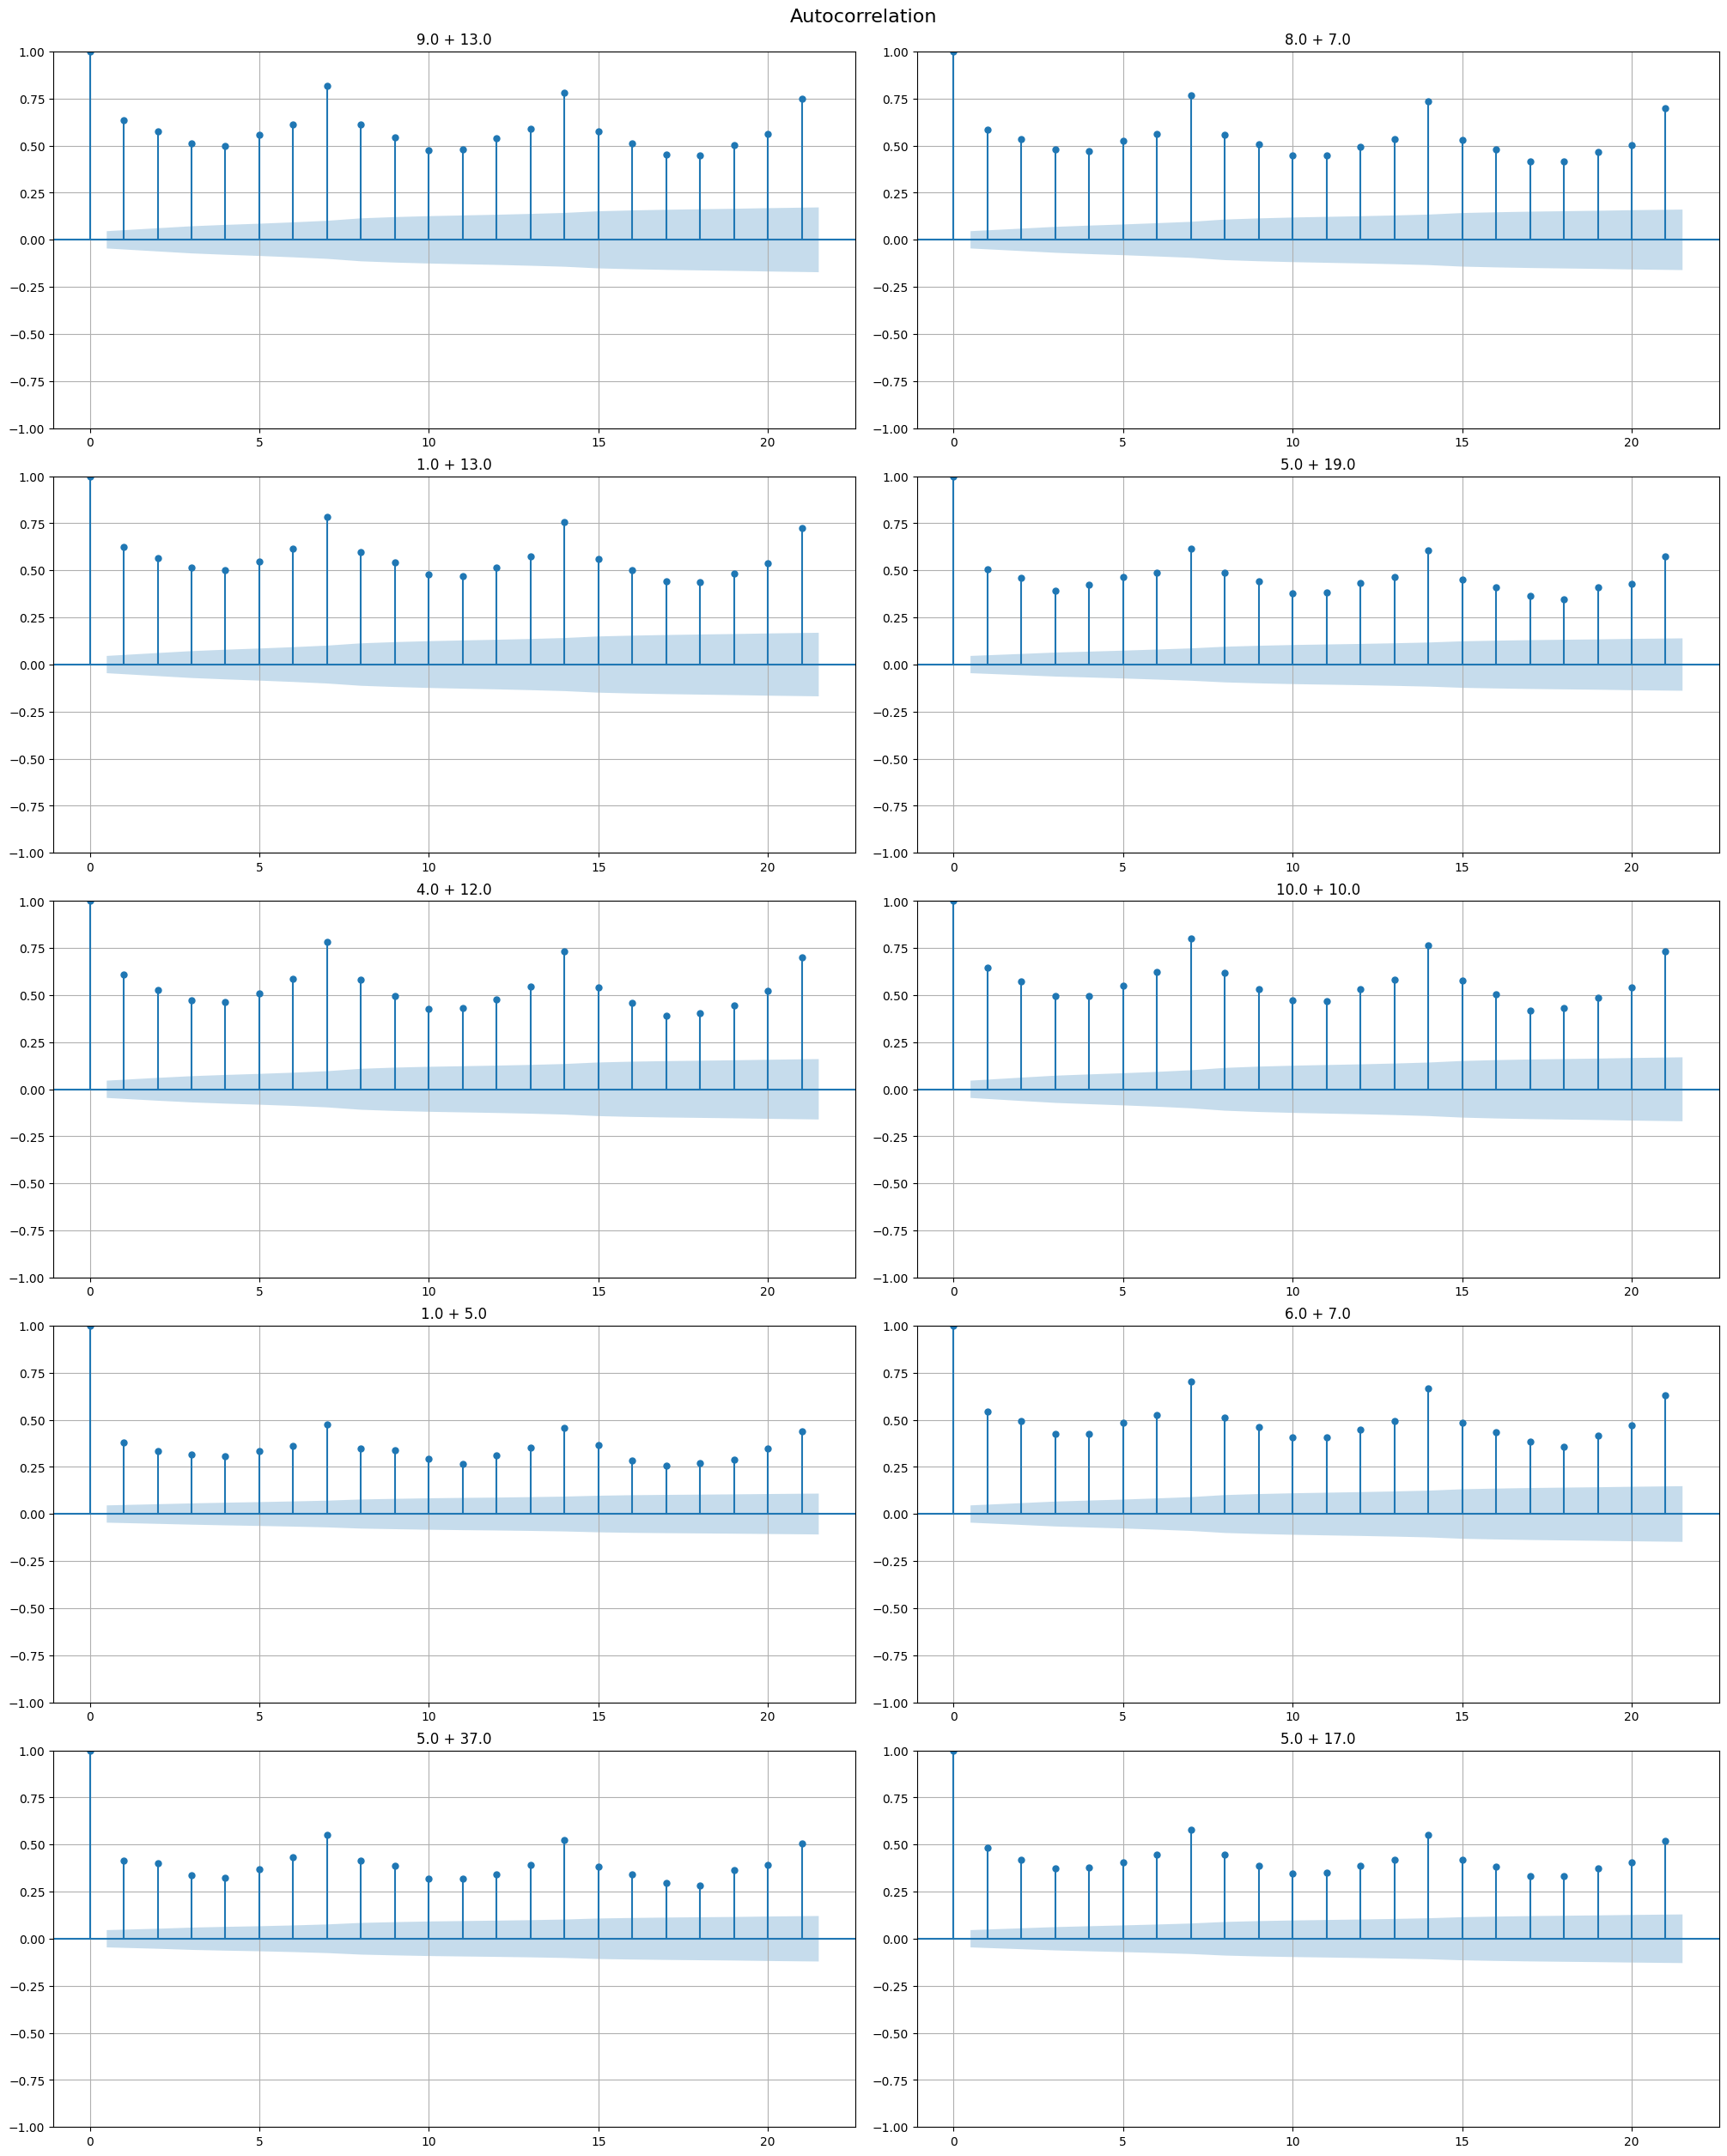

In [ ]:
from etna.analysis import acf_plot
from etna.analysis import plot_correlation_matrix
acf_plot(ts, lags=21) # дополнительно видна недельная сезоннсоть

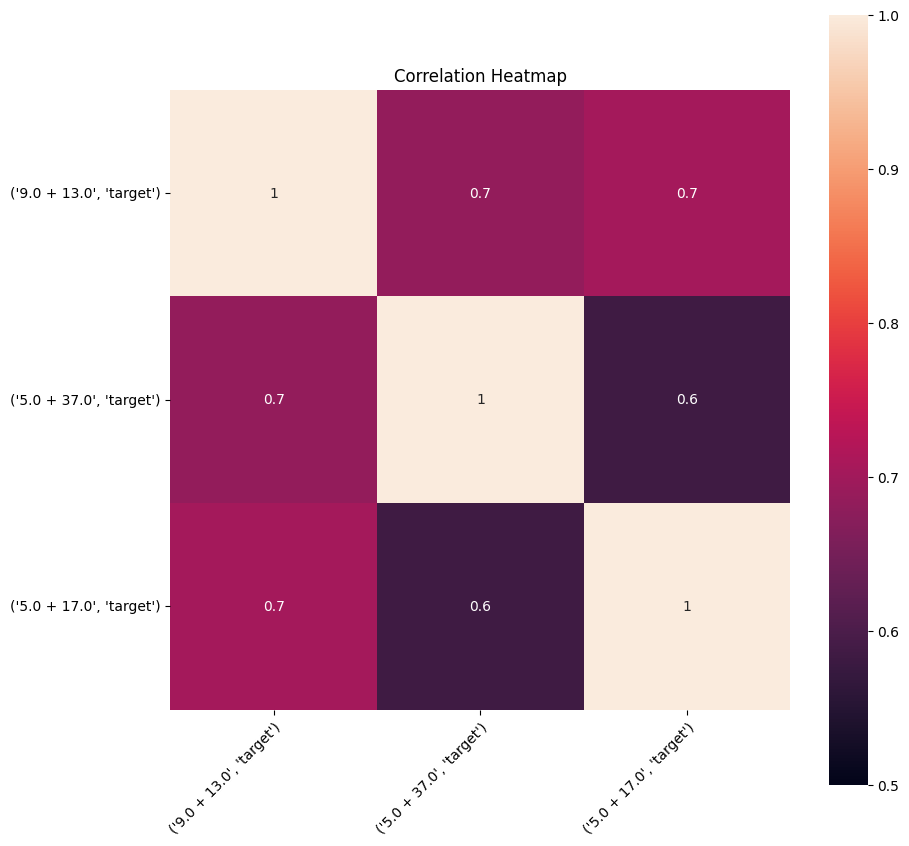

In [38]:
plot_correlation_matrix(ts, columns=['target'], segments=['9.0 + 13.0', "5.0 + 37.0", "5.0 + 17.0"], method="spearman", vmin=0.5, vmax=1)


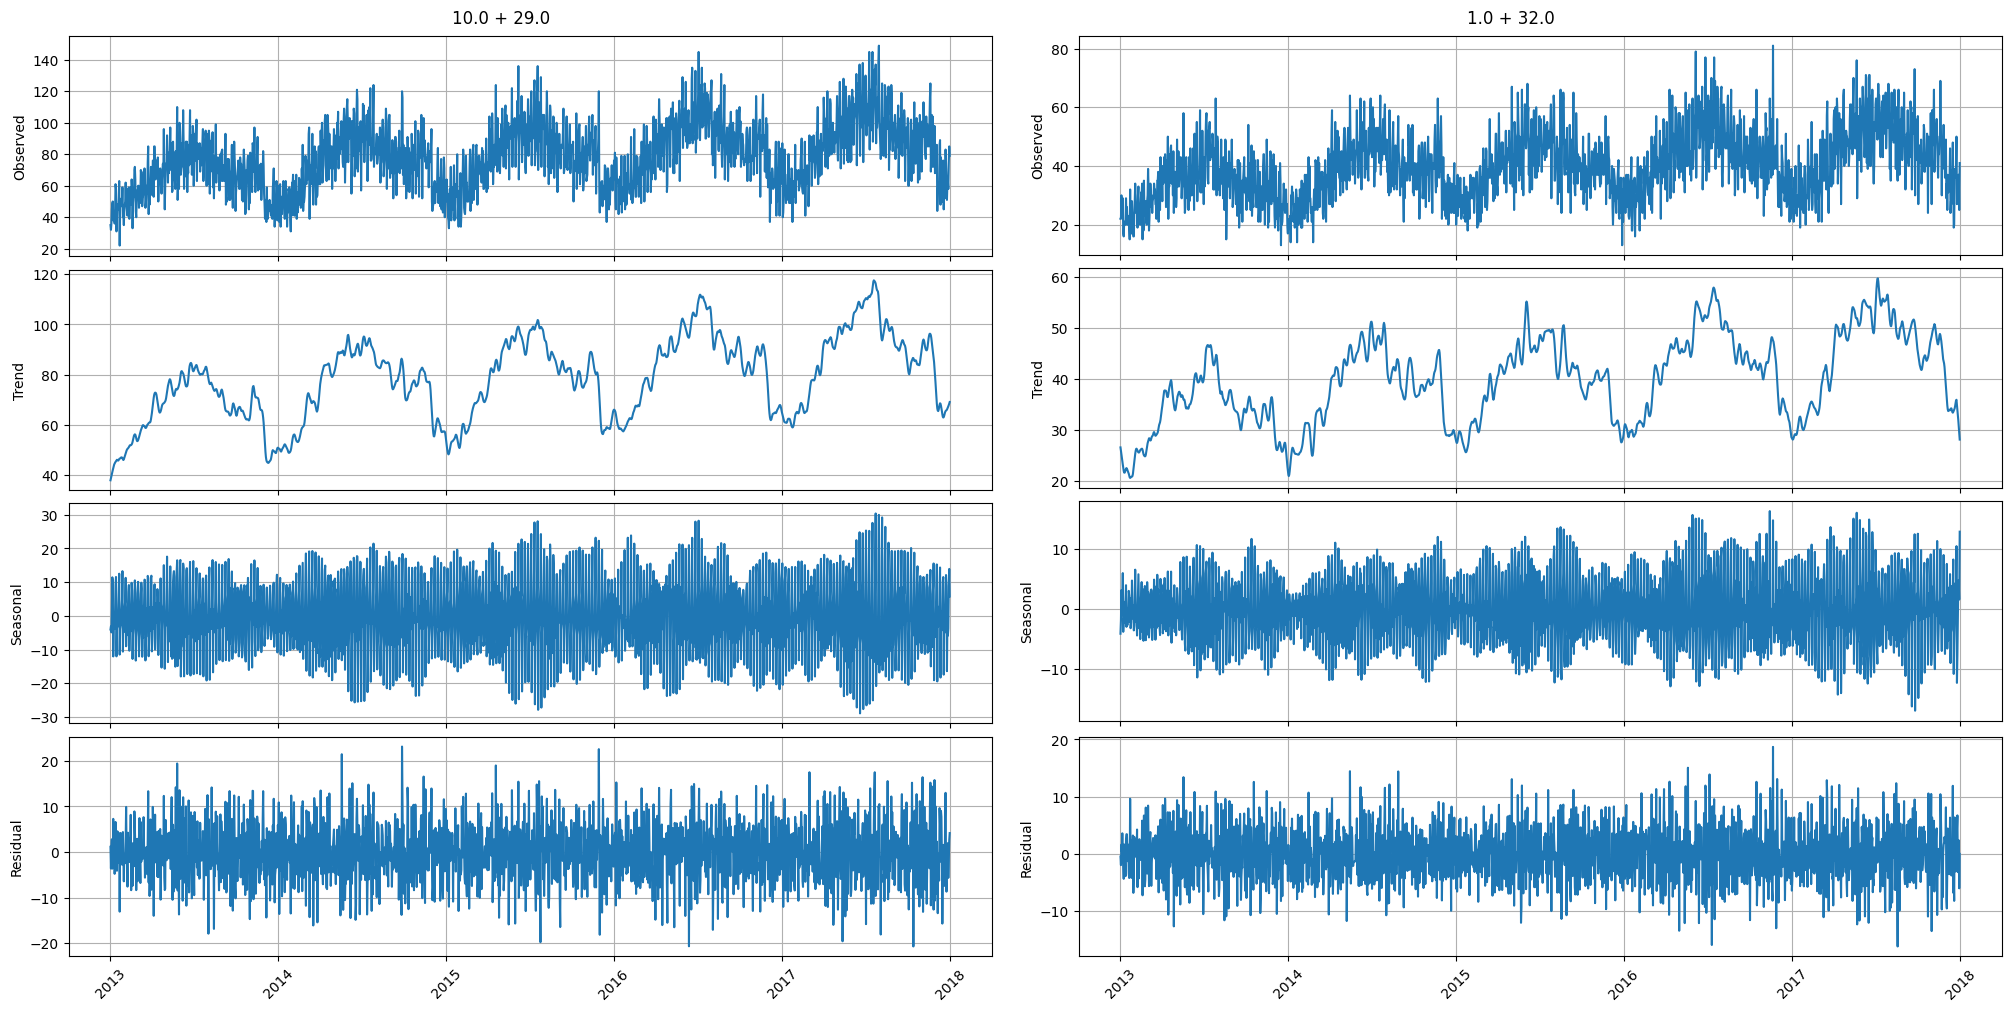

In [40]:
from etna.analysis import stl_plot
#декомпозиция
stl_plot(ts=ts, period=7, segments=['10.0 + 29.0', '1.0 + 32.0'])

In [62]:
from etna.transforms import MeanTransform, LagTransform, StandardScalerTransform
from etna.models import ElasticPerSegmentModel
from etna.models import ProphetModel
standardscaler = StandardScalerTransform(in_column=None)

mean7 = MeanTransform(in_column='target', 
                      window=7, 
                      out_column='mean_7')

elast_transforms = [mean7, standardscaler]

In [47]:
model=ElasticPerSegmentModel(l1_ratio=0, alpha=0, 
                                 random_state=42),

In [53]:
def train_and_evaluate_model(ts, 
                             model,
                             transforms,
                             horizon,
                             metrics,
                             print_metrics=False,
                             print_plots=False,
                             n_train_samples=None):
    """
    Обучает модель, вычисляет прогнозы для 
    тестовой выборки и строит график прогнозов.  
    """
    
    if not print_plots and n_train_samples is not None:
        raise ValueError(
            "Параметр n_train_samples задается при print_plots=True")
        
    train_ts, test_ts = ts.train_test_split(test_size=horizon)
    pipe = Pipeline(model=model,
                    transforms=transforms,
                    horizon=horizon)
    pipe.fit(train_ts)
    forecast_ts = pipe.forecast()
    
    segment_metrics = metrics(test_ts, forecast_ts)
    segment_metrics = pd.Series(segment_metrics)
    
    if print_metrics:
        print(segment_metrics.to_string())
        print("")
        print(f"Усредненная метрика:"
              f"{sum(segment_metrics) / len(segment_metrics)}")
    
    if print_plots:
        # визуализируем прогнозы, здесь n_train_samples
        # - n последних наблюдений в обучающей выборке
        plot_forecast(forecast_ts, test_ts, 
                      train_ts, n_train_samples=n_train_samples)


In [ ]:
train_and_evaluate_model(
    ts=ts, 
    model=model,
   transforms=elast_transforms,
    horizon=HORIZON,
    metrics=smape,
    print_metrics=True
   )

In [59]:
train_ts, test_ts = ts.train_test_split(train_start='2013-01-01',
                                        train_end='2015-12-01',
                                        test_start='2016-01-01',
                                        test_end='2017-12-31')

In [ ]:
train_ts,

In [70]:
model = ProphetModel()
model.fit(train_ts)
future_ts = train_ts.make_future(HORIZON)
forecast_ts = model.forecast(future_ts)

20:04:10 - cmdstanpy - INFO - Chain [1] start processing
20:04:10 - cmdstanpy - INFO - Chain [1] done processing


20:04:10 - cmdstanpy - INFO - Chain [1] start processing
20:04:10 - cmdstanpy - INFO - Chain [1] done processing
20:04:10 - cmdstanpy - INFO - Chain [1] start processing
20:04:10 - cmdstanpy - INFO - Chain [1] done processing
20:04:10 - cmdstanpy - INFO - Chain [1] start processing
20:04:10 - cmdstanpy - INFO - Chain [1] done processing
20:04:11 - cmdstanpy - INFO - Chain [1] start processing
20:04:11 - cmdstanpy - INFO - Chain [1] done processing
20:04:11 - cmdstanpy - INFO - Chain [1] start processing
20:04:11 - cmdstanpy - INFO - Chain [1] done processing
20:04:11 - cmdstanpy - INFO - Chain [1] start processing
20:04:11 - cmdstanpy - INFO - Chain [1] done processing
20:04:11 - cmdstanpy - INFO - Chain [1] start processing
20:04:11 - cmdstanpy - INFO - Chain [1] done processing
20:04:11 - cmdstanpy - INFO - Chain [1] start processing
20:04:11 - cmdstanpy - INFO - Chain [1] done processing
20:04:11 - cmdstanpy - INFO - Chain [1] start processing
20:04:12 - cmdstanpy - INFO - Chain [1]

In [69]:
# ХАК: временно добавляем np.NaN обратно
if not hasattr(np, 'NaN'):
    np.NaN = np.nan

# Теперь ваш код должен работать
try:
    # Ваш код с моделью
    forecast_ts = model.forecast(future_ts)
except AttributeError as e:
    if "np.NaN" in str(e):
        print("Ошибка с np.NaN, применяем исправление...")
        # Альтернативный способ: патчим проблемный модуль
        import statsmodels
        if hasattr(statsmodels, 'NaN'):
            statsmodels.NaN = np.nan
    raise

In [2]:
smape = SMAPE()
smape(y_true=test_ts, y_pred=forecast_ts)

NameError: name 'SMAPE' is not defined

In [1]:
plot_forecast(forecast_ts, test_ts, 
              train_ts, n_train_samples=10)

NameError: name 'plot_forecast' is not defined